# Combined Analysis and Modeling, Evaluation, Tuning of the Project
This notebook performs comprehensive EDA, statistical time-series analysis, and predictive modeling on the **entire dataset** across all stores and store types.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 1. Data Loading and Merging

In [2]:
train_df = pd.read_csv('../train.csv', low_memory=False)
store_df = pd.read_csv('../store.csv', low_memory=False)

# Merge datasets
df = pd.merge(train_df, store_df, on='Store', how='inner')

df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
print(f"Shape of entire dataset: {df.shape}")
df.head()

Shape of entire dataset: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1016473,379,2,2013-01-01,0,0,0,0,a,1,d,a,6630.0,NaN,NaN,0,NaN,NaN,NaN
1016472,378,2,2013-01-01,0,0,0,0,a,1,a,c,2140.0,8.0,2012.0,0,NaN,NaN,NaN
1016471,377,2,2013-01-01,0,0,0,0,a,1,a,c,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov"
1016470,376,2,2013-01-01,0,0,0,0,a,1,a,a,160.0,8.0,2012.0,0,NaN,NaN,NaN


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Summary statistics
display(df.describe())

# Missing values
print("Missing Values:")
display(df.isnull().sum())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846062080,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870


Missing Values:


Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

### 2.1 Univariate Analysis

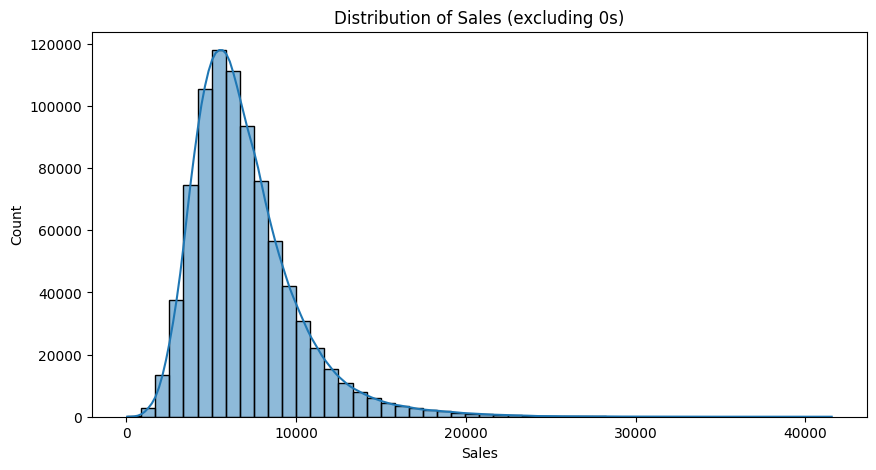

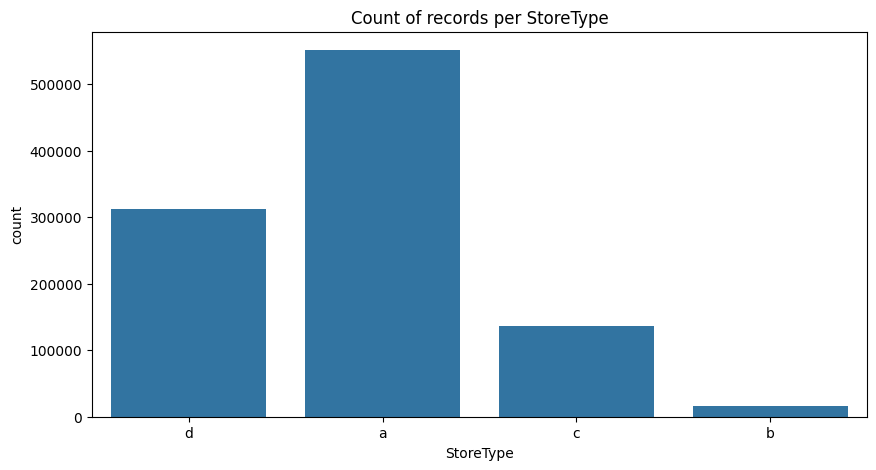

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Sales'] > 0]['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales (excluding 0s)')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x='StoreType', data=df)
plt.title('Count of records per StoreType')
plt.show()

### 2.2 BiVariate Analysis & Impact of Promotions

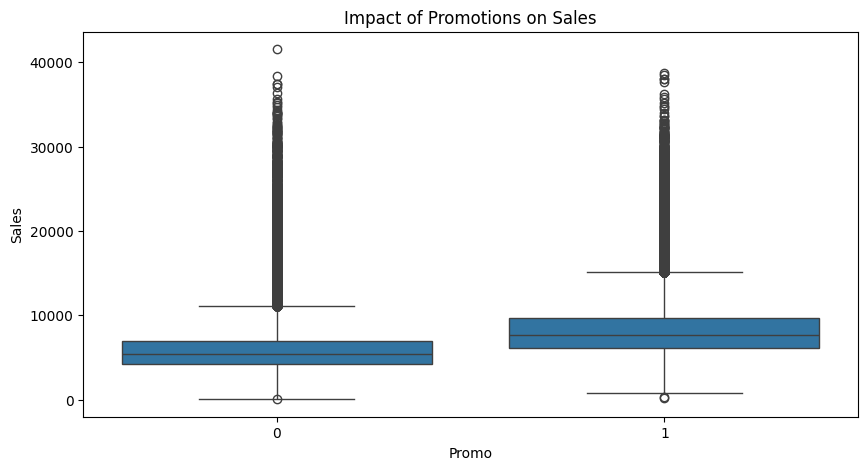

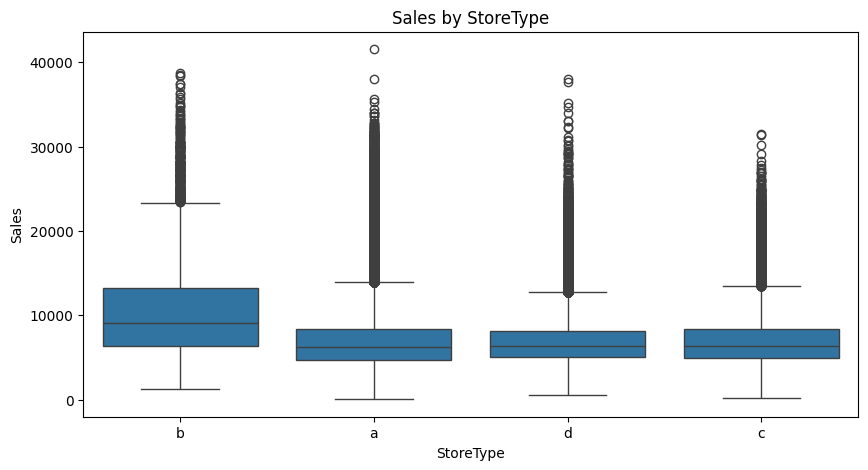

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Promo', y='Sales', data=df[df['Sales'] > 0])
plt.title('Impact of Promotions on Sales')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='StoreType', y='Sales', data=df[df['Sales'] > 0])
plt.title('Sales by StoreType')
plt.show()

### 2.3 Correlation Matrix for Numerical Columns

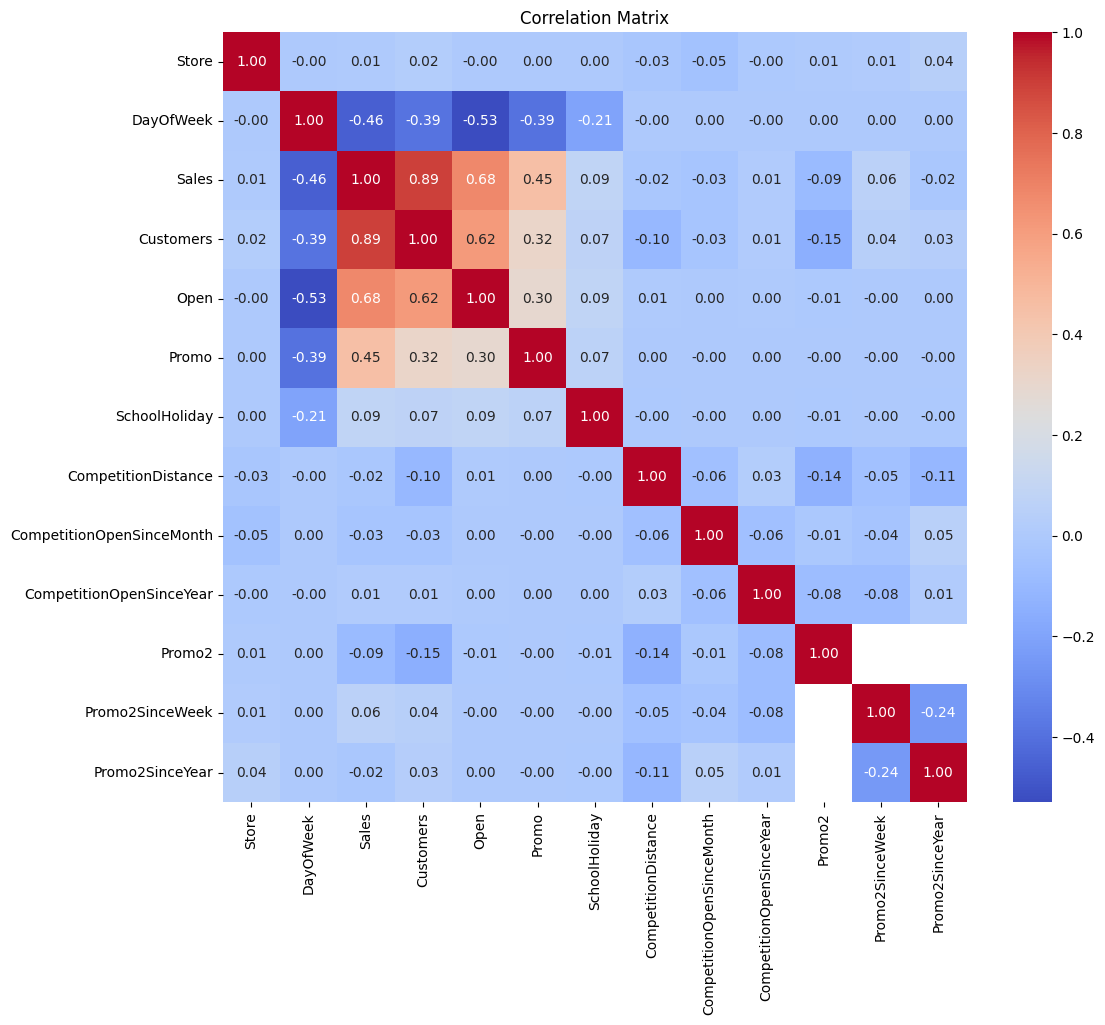

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 3. Time Series Analysis: Trend, Seasonality, and Stationarity

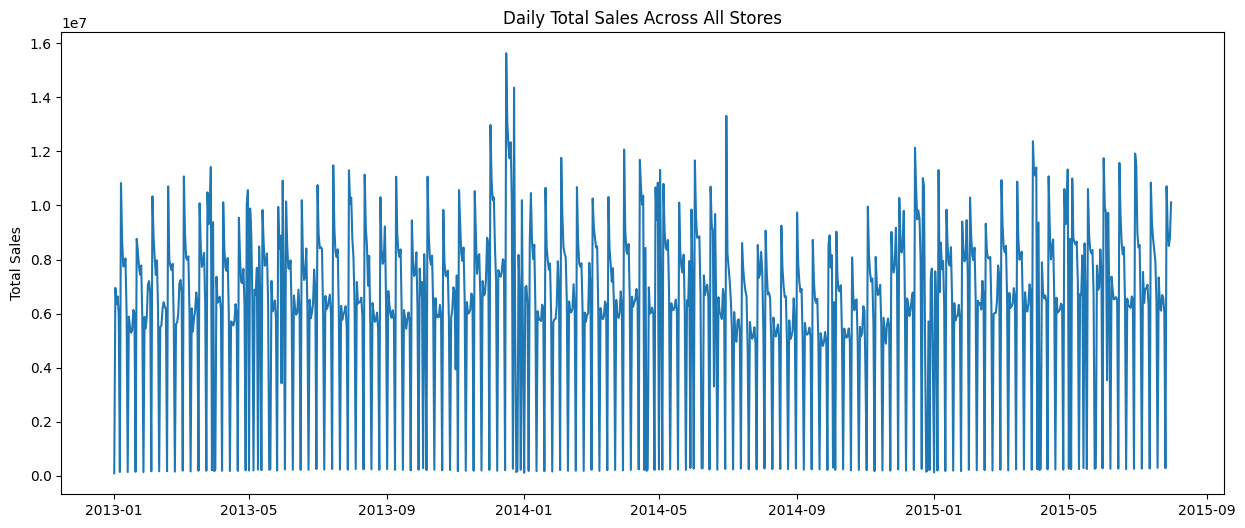

ADF Statistic: -4.761615
p-value: 0.000064
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568


In [7]:
# Aggregate daily sales across all stores
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()
daily_sales.set_index('Date', inplace=True)

plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales['Sales'])
plt.title('Daily Total Sales Across All Stores')
plt.ylabel('Total Sales')
plt.show()

# ADF Test for stationarity
result = adfuller(daily_sales['Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

## 4. Preprocessing and Feature Engineering

In [8]:
# Impute missing values
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)

# Date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# We only predict for open days
df_model = df[df['Open'] == 1].copy()

# One-hot encode categoricals
cat_cols = ['StoreType', 'Assortment', 'StateHoliday']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Define features for modeling
features = ['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Year', 'Month', 'Day'] + [c for c in df_model.columns if any(cat in c for cat in cat_cols)]
X = df_model[features]
y = df_model['Sales']

# Chronological Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

## 5. Linear Regression Model Training and Evaluation

In [9]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_preds))
print("Linear Regression R2:", r2_score(y_test, lr_preds))

Linear Regression RMSE: 2737.758984558089
Linear Regression MAE: 1986.5524702443984
Linear Regression R2: 0.20138760850877535


## 6. Time Series Model Building: Random Forest Regressor

Random Forest RMSE: 1096.635454708832
Random Forest MAE: 739.3428779185097
Random Forest R2: 0.8718642886558257


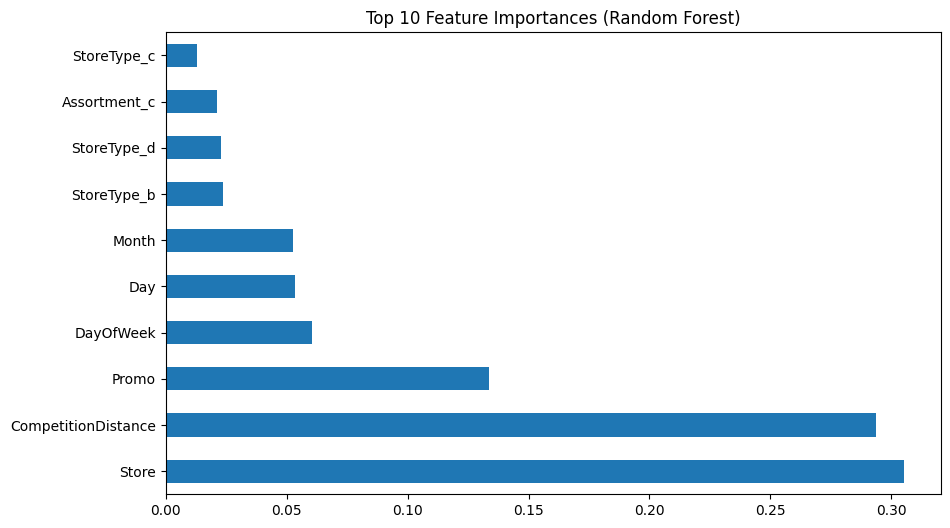

In [10]:
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_preds))
print("Random Forest R2:", r2_score(y_test, rf_preds))

# Feature Importances
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()

## 7. XGBoost Model with Hyperparameter Tuning

In [11]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=5, # Kept relatively small for execution speed on the entire dataset
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting XGBoost Hyperparameter Tuning on Global Data...")
random_search.fit(X_train, y_train)

print(f"Best parameters found: {random_search.best_params_}")
best_xgb = random_search.best_estimator_
xgb_preds = best_xgb.predict(X_test)

print("XGBoost (Tuned) RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))
print("XGBoost (Tuned) MAE:", mean_absolute_error(y_test, xgb_preds))
print("XGBoost (Tuned) R2:", r2_score(y_test, xgb_preds))

Starting XGBoost Hyperparameter Tuning on Global Data...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters found: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
XGBoost (Tuned) RMSE: 1629.1806222761184
XGBoost (Tuned) MAE: 1168.7413330078125
XGBoost (Tuned) R2: 0.7171969413757324


## 8. SARIMA Model Building (Statistical Time-Series)
Here we model the aggregated daily sales globally using SARIMA to capture seasonal trends explicitly.

Training SARIMA model... (this may take a moment)


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                  753
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -11765.287
Date:                           Wed, 26 Aug 2026   AIC                          23540.575
Time:                                   10:38:54   BIC                          23563.581
Sample:                               01-01-2013   HQIC                         23549.447
                                    - 01-23-2015                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2249      0.052      4.297      0.000       0.122       0.327
ma.L1         -0.9499      0.022    -43.366

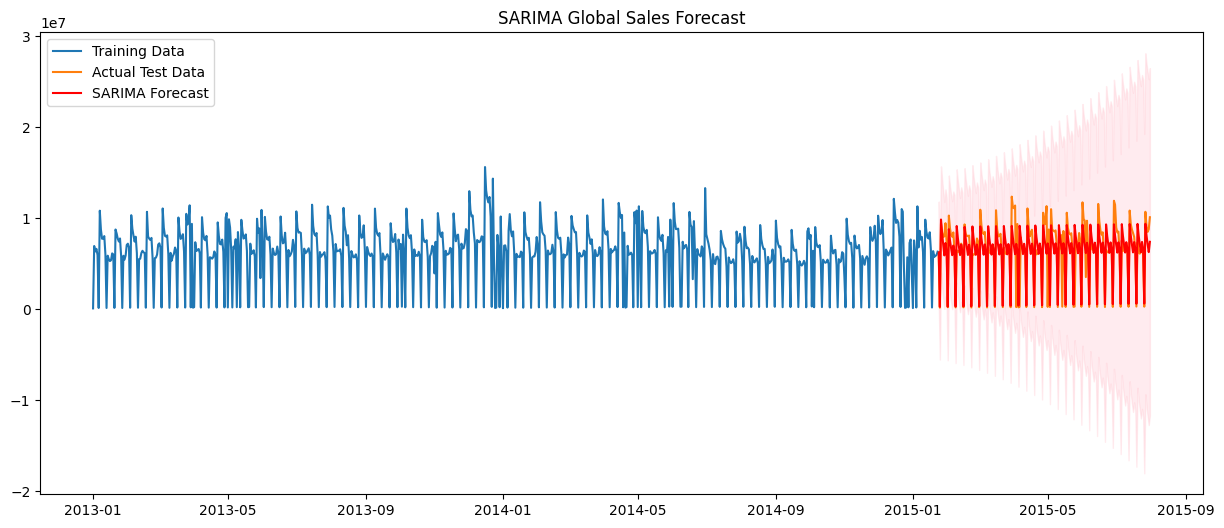

SARIMA RMSE: 1941776.537597452
SARIMA MAE: 1310832.0808420095


In [12]:
import statsmodels.api as sm

# We use the daily_sales dataframe aggregated earlier
# We will split it chronologically
train_size = int(len(daily_sales) * 0.8)
train_ts, test_ts = daily_sales.iloc[:train_size], daily_sales.iloc[train_size:]

print("Training SARIMA model... (this may take a moment)")
# SARIMA parameters: (p,d,q) x (P,D,Q,s)
# Using generic parameters for weekly seasonality (s=7)
sarima_model = sm.tsa.statespace.SARIMAX(
    train_ts['Sales'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

# Forecast
forecast = sarima_result.get_forecast(steps=len(test_ts))
predictions = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plotting the SARIMA forecast
plt.figure(figsize=(15, 6))
plt.plot(train_ts.index, train_ts['Sales'], label='Training Data')
plt.plot(test_ts.index, test_ts['Sales'], label='Actual Test Data')
plt.plot(test_ts.index, predictions, color='red', label='SARIMA Forecast')
plt.fill_between(test_ts.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Global Sales Forecast')
plt.legend()
plt.show()

print("SARIMA RMSE:", np.sqrt(mean_squared_error(test_ts['Sales'], predictions)))
print("SARIMA MAE:", mean_absolute_error(test_ts['Sales'], predictions))